1. Problem Definition
2. Data Preparation for ML
3. Baseline Model (Logistic Regression)
4. Improved Models (Random Forest + Class Imbalance)
5. Model Comparison & Insights


# Level 3 – Machine Learning for Accident Severity Prediction

Objective:
Predict accident severity using structured accident data and
evaluate model performance with special focus on severe outcomes
(Fatal and Serious accidents).


In [1]:
import pandas as pd

df = pd.read_csv("../data/Road accident.csv")

features = [
    'Day_of_Week', 'Light_Conditions', 'Weather_Conditions',
    'Road_Type', 'Urban_or_Rural_Area', 'Vehicle_Type',
    'Speed_limit', 'Number_of_Vehicles', 'Number_of_Casualties'
]

target = 'Accident_Severity'

df = df[features + [target]].dropna()


In [2]:
severity_map = {
    'Slight': 0,
    'Serious': 1,
    'Fatal': 2
}

df['Severity_Label'] = df[target].map(severity_map)


In [4]:
df['Severity_Label'].value_counts(dropna=False)


Severity_Label
0.0    263280
1.0     40740
2.0      3904
NaN        49
Name: count, dtype: int64

In [5]:
df = df.dropna(subset=['Severity_Label'])


In [6]:
X = df[features]
y = df['Severity_Label']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Identify categorical & numerical columns
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

# Preprocessing
preprocess = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
    
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols)
])

# Logistic Regression pipeline
log_reg = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])


In [10]:
from sklearn.metrics import classification_report

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     52656
         1.0       0.25      0.00      0.00      8148
         2.0       0.00      0.00      0.00       781

    accuracy                           0.85     61585
   macro avg       0.37      0.33      0.31     61585
weighted avg       0.76      0.85      0.79     61585



### Baseline Model Observation

- Logistic Regression achieved high overall accuracy due to class imbalance.
- However, the model failed to correctly identify Serious and Fatal accidents.
- Recall for severe classes was zero, making the model unsuitable for safety-critical predictions.
- This highlights the limitation of accuracy as a sole evaluation metric.


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])


In [12]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

         0.0       0.89      0.66      0.76     52656
         1.0       0.18      0.34      0.24      8148
         2.0       0.03      0.27      0.05       781

    accuracy                           0.61     61585
   macro avg       0.37      0.42      0.35     61585
weighted avg       0.78      0.61      0.68     61585



### Improved Model Observation (Random Forest with Class Balancing)

- Overall accuracy decreased compared to Logistic Regression due to reduced bias toward the majority class.
- Recall for Serious and Fatal accidents improved significantly.
- The model successfully identified severe accidents that were completely missed by the baseline model.
- This demonstrates the importance of handling class imbalance and prioritizing recall over accuracy in safety-critical applications.



## Feature Importance Analysis (Model Explainability)

This section identifies the most influential factors contributing to accident severity
using the trained Random Forest model.


In [13]:
# Get preprocessing step
preprocessor = rf.named_steps['preprocess']

# Get categorical feature names
cat_features = preprocessor.named_transformers_['cat'] \
    .named_steps['ohe'].get_feature_names_out(cat_cols)

# Combine with numerical features
feature_names = list(cat_features) + list(num_cols)


In [14]:
import pandas as pd

importances = rf.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


,Feature,Importance
43,Number_of_Vehicles,0.150284
44,Number_of_Casualties,0.137239
42,Speed_limit,0.135740
29,Vehicle_Type_Car,0.032657
0,Day_of_Week_Friday,0.026704
25,Urban_or_Rural_Area_Rural,0.025177
4,Day_of_Week_Thursday,0.024995
26,Urban_or_Rural_Area_Urban,0.024703
1,Day_of_Week_Monday,0.024345
2,Day_of_Week_Saturday,0.023911


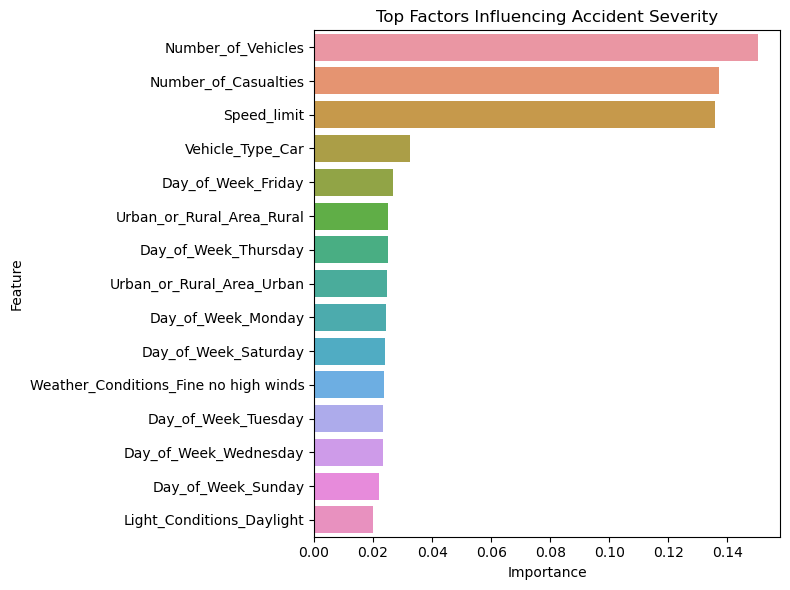

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)
plt.title('Top Factors Influencing Accident Severity')
plt.tight_layout()
plt.show()


### Feature Importance Interpretation

- The number of vehicles involved is the strongest predictor of accident severity, indicating higher risk in multi-vehicle collisions.
- Speed limit is a critical driver, reinforcing the role of high-speed environments in fatal and serious accidents.
- Rural road conditions contribute more strongly to severity compared to urban areas.
- Environmental and temporal factors such as lighting, weather, and day of week further influence accident outcomes.
- These findings align with statistical tests and domain knowledge, strengthening model credibility.
